In [104]:
import pandas as pd
import numpy as np

In [105]:
df=pd.read_csv(r'C:\Users\DELL\Desktop\Data Science\IEP\AI Resume screening\ai_resume_screening.csv')

In [106]:
df.head()

,years_experience,skills_match_score,education_level,project_count,resume_length,github_activity,shortlisted
0,6,84.7,Bachelors,7,234,158,No
1,3,59.1,Masters,5,502,77,No
2,12,100.0,Masters,12,753,381,Yes
3,14,66.8,High School,8,529,407,Yes
4,10,99.6,Bachelors,10,754,331,Yes


In [107]:
df.describe()

,years_experience,skills_match_score,project_count,resume_length,github_activity
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,7.506567,73.682653,10.646267,572.584700,325.260667
std,4.624104,16.765909,4.634047,178.709918,159.951803
min,0.000000,0.500000,0.000000,150.000000,0.000000
25%,3.750000,62.100000,7.000000,441.000000,202.000000
50%,7.000000,74.300000,10.000000,574.000000,321.000000
75%,12.000000,86.500000,14.000000,709.000000,443.000000
max,15.000000,100.000000,25.000000,900.000000,842.000000


In [108]:



df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   years_experience    30000 non-null  int64  
 1   skills_match_score  30000 non-null  float64
 2   education_level     30000 non-null  object 
 3   project_count       30000 non-null  int64  
 4   resume_length       30000 non-null  int64  
 5   github_activity     30000 non-null  int64  
 6   shortlisted         30000 non-null  object 
dtypes: float64(1), int64(4), object(2)
memory usage: 1.6+ MB


In [109]:
df.shape

(30000, 7)

In [110]:
df.dtypes

years_experience        int64
skills_match_score    float64
education_level        object
project_count           int64
resume_length           int64
github_activity         int64
shortlisted            object
dtype: object

# Data Cleaning

### Null Values

In [111]:
df.isnull().sum()

years_experience      0
skills_match_score    0
education_level       0
project_count         0
resume_length         0
github_activity       0
shortlisted           0
dtype: int64

### Duplicate Values

In [112]:
print(df.duplicated().sum())

0


### Outlier Analysis

In [113]:
import numpy as np
df.select_dtypes(include=np.number)

,years_experience,skills_match_score,project_count,resume_length,github_activity
0,6,84.7,7,234,158
1,3,59.1,5,502,77
2,12,100.0,12,753,381
3,14,66.8,8,529,407
4,10,99.6,10,754,331
...,...,...,...,...,...
29995,9,77.4,13,691,434
29996,5,77.8,9,473,149
29997,1,64.6,7,247,82
29998,7,94.8,12,584,409


In [114]:
import seaborn as sns

<Axes: >

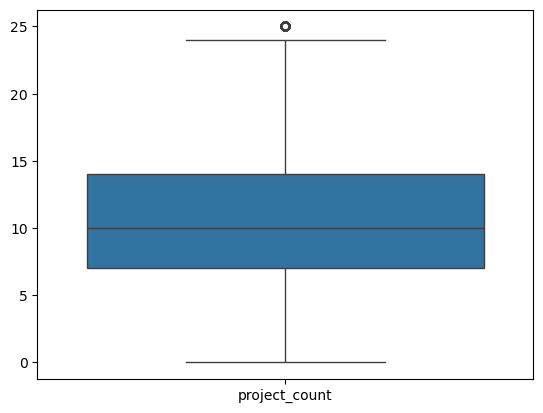

In [115]:
sns.boxplot([df["project_count"]])

# IQR

In [116]:
a=df.select_dtypes(include=np.number)

In [117]:
for i in a:
    q1=a[i].quantile(0.25)
    q2=a[i].quantile(0.50)
    q3=a[i].quantile(0.75)

In [118]:
IQR=q3-q1

In [119]:
Uw=q3+1.5*IQR
Lw=q1-1.5*IQR

In [120]:
outliers=((a[i]>Uw)|(a[i]<Lw))

In [121]:
print(i,":",outliers.sum())

github_activity : 9


# Exploratory Data Analysis

In [122]:
df.head()

,years_experience,skills_match_score,education_level,project_count,resume_length,github_activity,shortlisted
0,6,84.7,Bachelors,7,234,158,No
1,3,59.1,Masters,5,502,77,No
2,12,100.0,Masters,12,753,381,Yes
3,14,66.8,High School,8,529,407,Yes
4,10,99.6,Bachelors,10,754,331,Yes


In [123]:
df['shortlisted'].value_counts()

shortlisted
Yes    20966
No      9034
Name: count, dtype: int64

In [124]:
df['education_level'].value_counts()

education_level
Bachelors      13461
Masters        10524
PhD             3024
High School     2991
Name: count, dtype: int64

In [125]:
a=pd.DataFrame(df.groupby("shortlisted")['years_experience'].mean().sort_values(ascending=False))
a.to_csv('shortlisted')

In [126]:
b=pd.DataFrame(df.groupby("shortlisted")['skills_match_score'].mean().sort_values(ascending=False))
b.to_csv('skills')

In [127]:
c=pd.DataFrame(df.groupby('education_level')['project_count'].count().sort_values(ascending=False))
c.to_csv('education_level')

In [128]:
d=pd.DataFrame(df.groupby('education_level')['github_activity'].count().sort_values(ascending=False))
d.to_csv('github')

In [129]:
e=pd.DataFrame(df.groupby('project_count')['years_experience'].sum().sort_values(ascending=False))
e.to_csv('projects')

In [ ]:
f=pd.DataFrame(df.groupby('shortlisted')['education_level'].sum().sort_values(ascending=False))
f.to_csv('shortlisted_level')

In [131]:
import os

In [132]:
os.getcwd()

'C:\\Users\\DELL'

# Data Preprocessing

In [133]:
df.head()

,years_experience,skills_match_score,education_level,project_count,resume_length,github_activity,shortlisted
0,6,84.7,Bachelors,7,234,158,No
1,3,59.1,Masters,5,502,77,No
2,12,100.0,Masters,12,753,381,Yes
3,14,66.8,High School,8,529,407,Yes
4,10,99.6,Bachelors,10,754,331,Yes


In [134]:
from sklearn.preprocessing import LabelEncoder

In [135]:
for i in df:
    df[i]=LabelEncoder().fit_transform(df[i])

In [136]:
df

,years_experience,skills_match_score,education_level,project_count,resume_length,github_activity,shortlisted
0,6,641,0,7,84,158,0
1,3,385,2,5,352,77,0
2,12,794,2,12,603,381,1
3,14,462,1,8,379,407,1
4,10,790,0,10,604,331,1
...,...,...,...,...,...,...,...
29995,9,568,0,13,541,434,1
29996,5,572,0,9,323,149,0
29997,1,440,0,7,97,82,0
29998,7,742,0,12,434,409,1


## Feature Extraction

In [137]:
y=df["shortlisted"]
x=df.drop("shortlisted",axis=1)

## Train-Test Split

In [138]:
from sklearn.model_selection import train_test_split

In [139]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

## Model Deployment

In [140]:
from sklearn.linear_model import LogisticRegression

In [141]:
model=LogisticRegression()

In [142]:
model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [143]:
model.fit(x_train,y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## Prediction

In [144]:
y_pred=model.predict(x_test)

In [145]:
y_test

2368     1
932      0
1151     1
22645    1
5344     1
        ..
21764    0
20751    0
29938    1
10047    1
11276    1
Name: shortlisted, Length: 6000, dtype: int64

In [146]:
y_pred

array([1, 0, 1, ..., 1, 1, 1], shape=(6000,))

## Accuracy

In [147]:
from sklearn.metrics import accuracy_score

In [148]:
accuracy_score(y_test,y_pred)

0.9051666666666667